In [1]:
pip install pandas matplotlib openpyxl

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 7.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.8 MB 7.7 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.8 MB 7.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.8 MB 8.1 MB


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Titanic.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  
0      0         A/5 21171   7.2500  
1      0          PC 17599  71.2833  
2      0  STON/O2. 3101282   7.9250  
3      0            113803  53.1000  
4      0            373450   8.0500  


In [4]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(891, 10)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare'],
      dtype='str')


In [6]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
dtypes: float64(2), int64(5), str(3)
memory usage: 69.7 KB
None


In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [8]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [10]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [12]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
dtype: object


In [13]:
df["Sex"] = df["Sex"].str.lower().str.strip()
df["Name"] = df["Name"].str.title()

In [14]:
df.to_csv("Titanic_Cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [15]:
report = pd.DataFrame({
    "Total Rows":[len(df)],
    "Total Columns":[len(df.columns)],
    "Missing Values":[df.isnull().sum().sum()],
    "Duplicate Rows":[df.duplicated().sum()]
})

print(report)
report.to_excel("Automation_Report.xlsx", index=False)

   Total Rows  Total Columns  Missing Values  Duplicate Rows
0         891             10               0               0


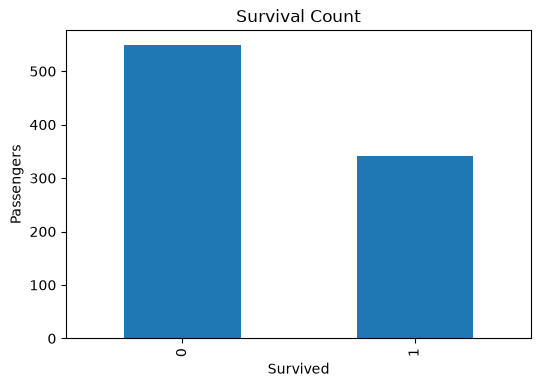

In [16]:
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.savefig("Survival_Count.png")
plt.show()

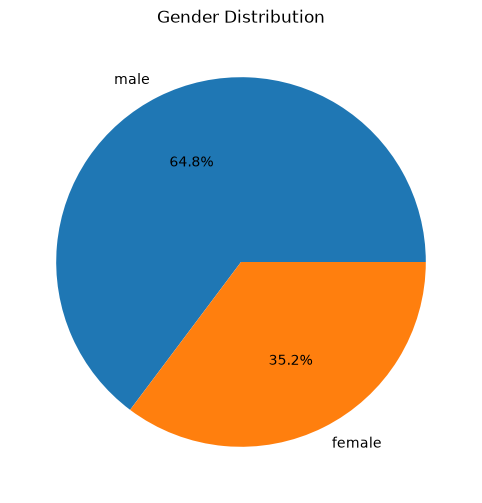

In [17]:
plt.figure(figsize=(6,6))
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Gender Distribution")
plt.savefig("Gender_Distribution.png")
plt.show()

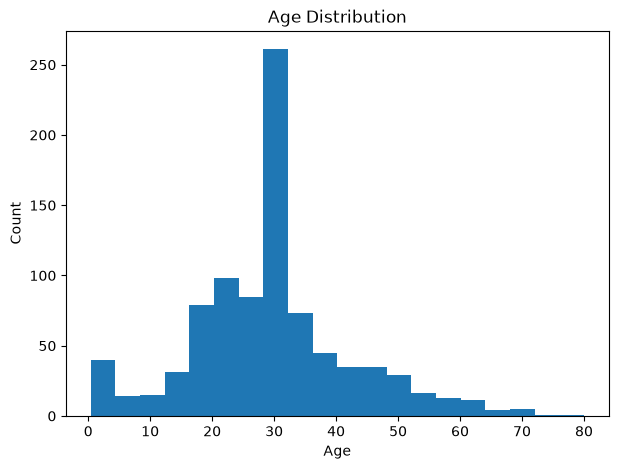

In [18]:
plt.figure(figsize=(7,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.savefig("Age_Distribution.png")

plt.show()

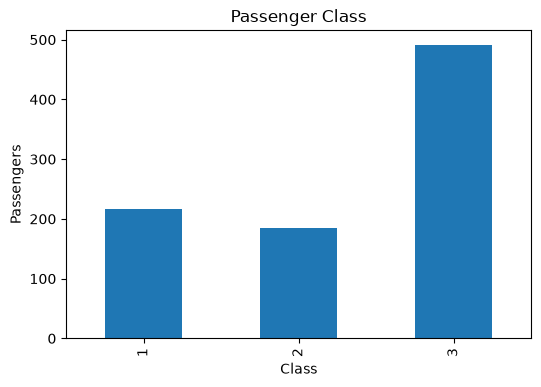

In [19]:
plt.figure(figsize=(6,4))

df["Pclass"].value_counts().sort_index().plot(kind="bar")

plt.title("Passenger Class")

plt.xlabel("Class")

plt.ylabel("Passengers")

plt.savefig("Passenger_Class.png")

plt.show()

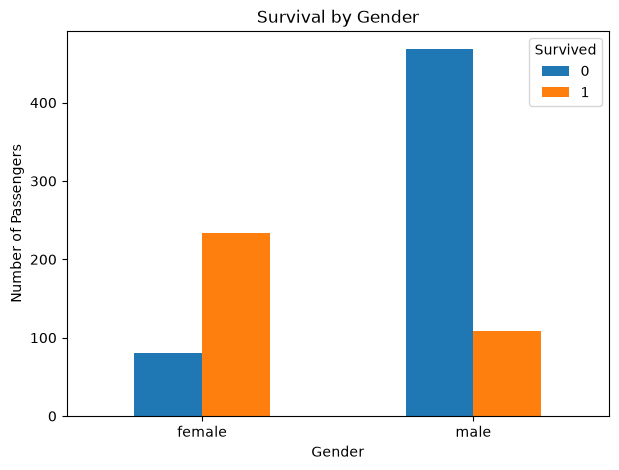

In [20]:
import matplotlib.pyplot as plt

survival_gender = pd.crosstab(df['Sex'], df['Survived'])

survival_gender.plot(kind='bar', figsize=(7,5))

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

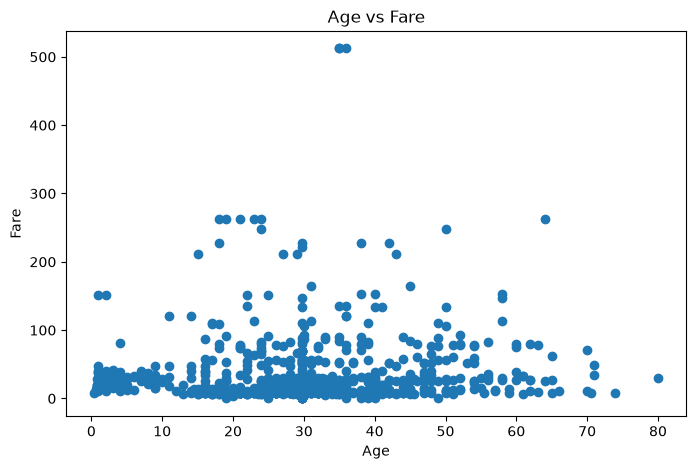

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [22]:
print("="*40)
print("DATA CLEANING COMPLETED")
print("="*40)

print("Rows :", len(df))
print("Columns :", len(df.columns))
print("Missing Values :", df.isnull().sum().sum())
print("Duplicates :", df.duplicated().sum())

print("\nFiles Generated")

print("1. Titanic_Cleaned.csv")
print("2. Automation_Report.xlsx")
print("3. Survival_Count.png")
print("4. Gender_Distribution.png")
print("5. Age_Distribution.png")
print("6. Passenger_Class.png")

DATA CLEANING COMPLETED
Rows : 891
Columns : 10
Missing Values : 0
Duplicates : 0

Files Generated
1. Titanic_Cleaned.csv
2. Automation_Report.xlsx
3. Survival_Count.png
4. Gender_Distribution.png
5. Age_Distribution.png
6. Passenger_Class.png
